# Research Notebook
## Salaheeddine Hafne
## Date: Feb10-28

# 1: Experience

Firstly, I worked on creating a single code that can return a value for baryonic potential for any galaxy at any radius r, which was provided to the data team. Then a graph of a vs M_b was plotted to ensure data consistency. After that, I ran the emcmc example file provided on discord making both main plots of the guesser values (ensuring to remove the burnins) and creating corner plots. Finally I created a verification plot ensuring that our best fit model for any galaxy matches the SPARC data points for that galaxy.

## Motivation:

The tasks completed this week allowed us to move towards the final steps of the baryon team and begin integrating with the data team to finalize the research for the semester. At this point most of the heavy lifting has already been completed so most of the work consisted of combining codes to create a final script.

# 2: What?(What happened?):
The focus of this week was the transition from independent baryonic modeling to integrated Markov Chain Monte Carlo (MCMC) analysis and model verification. This required transitioning our static Hernquist fits into a dynamic framework capable of being sampled by the emcee ensemble sampler. We successfully established a pipeline that reads MCMC backends, diagnoses chain convergence, and performs a physical "sanity check" by overlaying the maximum likelihood model against the SPARC rotation curve data. Regarding the technical implementation, we finalized the phi_Hern_sph function factory to provide the Data Team with a consistent gravitational potential $\Phi_b(r) = -GM_b / (r + a)$, allowing the Jeans modeling package to sum the baryonic and dark matter potentials in quadrature: $V_{total} = \sqrt{V_{bar}^2 + V_{DM}^2}$. For the MCMC diagnostics, we implemented a suite using emcee and h5py to read .h5 backends, specifically applying a "burn-in" removal of 1,000 steps to discard the unstable initial "climb" of the walkers. We then utilized the corner package to visualize the multidimensional probability distributions of our parameters. A critical part of the week involved parameter mapping and correctiing the following feedback regarding unphysical mass results where $log_{10}M_{200}$ appeared as $\approx 0.26$. We identified a label-mapping error in the backend and correctly re-indexed the parameters to Index 0 for $log_{10}(r_1)$, Index 1 for $log_{10}(M_{200})$, and Index 2 for $\delta log_{10}(c)$. This correction updated the halo mass for UGC02953 to a physically valid $\approx 10^{12.1} M_{\odot}$. Finally, for model verification, we used np.argmax on the log-likelihoods to extract the "Best Fit" parameters and generate a total velocity profile. Overlaying this profile on the SPARC data for UGC02953 confirmed that while the inner 10 kpc fits the peak velocity of $\approx 310$ km/s accurately, the model currently underpredicts the "flatness" of the outer rotation curve beyond 40 kpc.
## key equations:
Mass-Concentration Relation: $c = 10^{(0.905 - 0.101 \cdot \log_{10}(h \cdot M_{200} / 10^{12}))} \cdot 10^{\delta \log c}    
$Best Fit Extraction: $\theta_{best} = \text{argmax}(\ln \mathcal{L})  
$Quadrature Summation: $V_{total}(r) = \sqrt{V_{Hernquist}(r)^2 + V_{Jeans}(r)^2}$
## This weeks code:
The following is the emcmc code that allowed us to run the h5 test file:
import emcee
import h5py
import matplotlib.pyplot as plt
import corner
import numpy as np

#Setup the File Path
file_path = "UGC02953_sph_mcmc_nw_32_ni_10000.h5"

#Initialize the Reader
reader = emcee.backends.HDFBackend(file_path, read_only=True)

#Extracting Samples
#remove the first 1000 steps as 'burn-in' to ensure we only look at converged data
#We thin by 15 to reduce correlation between steps
samples = reader.get_chain(discard=1000, thin=15, flat=True)
log_prob = reader.get_log_prob(discard=1000, thin=15, flat=True)

print(f"Successfully loaded {len(samples)} samples from UGC02953.")

#Generate Trace Plots (Diagnostic Check)
full_chain = reader.get_chain()
ndim = full_chain.shape[2]

labels = ["log_r1", "log_M200", "delta_log_c"] 

fig, axes = plt.subplots(ndim, figsize=(10, 2 * ndim), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(full_chain[:, :, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
plt.xlabel("Step Number")
plt.tight_layout()
plt.show()

#Generate Corner Plot 
fig = corner.corner(
    samples, 
    labels=labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3f"
)
plt.show()

The following is the plot of our best fit model vs the SPARC data points:

import numpy as np
import matplotlib.pyplot as plt
import emcee
import h5py
from readData import get_rc_data 

#Setup and Load Data
GalaxyID = "UGC02953" 
file_path = "UGC02953_sph_mcmc_nw_32_ni_10000.h5"
reader = emcee.backends.HDFBackend(file_path, read_only=True)

#Extract Best Fit using np.argmax 
#log_prob shape (niter, nwalkers)
log_prob = reader.get_log_prob(discard=1000, flat=True)
samples = reader.get_chain(discard=1000, flat=True)

best_idx = np.argmax(log_prob)
best_theta = samples[best_idx]

r1_fit = 10**best_theta[0]
M200_fit = 10**best_theta[1]
dlogc_fit = best_theta[2]

#Get the Best Fit Rotation Curve from Blobs
#The Data Team saves the velocity model as a blob in the h5 file
blobs = reader.get_blobs(discard=1000, flat=True)
v_model_best = blobs["rotation-curve"][best_idx]

#Load Original SPARC Data for Comparison
data, _, _ = get_rc_data(GalaxyID)
r_data = data["Rad"].values
v_data = data["Vobs"].values
v_err = data["errV"].values

#Final Plotting
plt.figure(figsize=(10, 6))

#Plot the real data points
plt.errorbar(r_data, v_data, yerr=v_err, fmt='ko', label='SPARC Data', markersize=4, capsize=3)

#Plot the MCMC Best Fit line
plt.plot(r_data, v_model_best, 'r-', linewidth=2, label='MCMC Best Fit Model')

plt.xlabel('Radius (kpc)')
plt.ylabel('Velocity (km/s)')
plt.title(f'Rotation Curve Verification: {GalaxyID}')
plt.legend()
plt.grid(alpha=0.3)

print(f"Verification Results for {GalaxyID}:")
print(f"Best log_M200: {best_theta[1]:.3f}")
print(f"Best r1: {r1_fit:.3f} kpc")
plt.show()

Here are both out puts including the corner plots aswell:
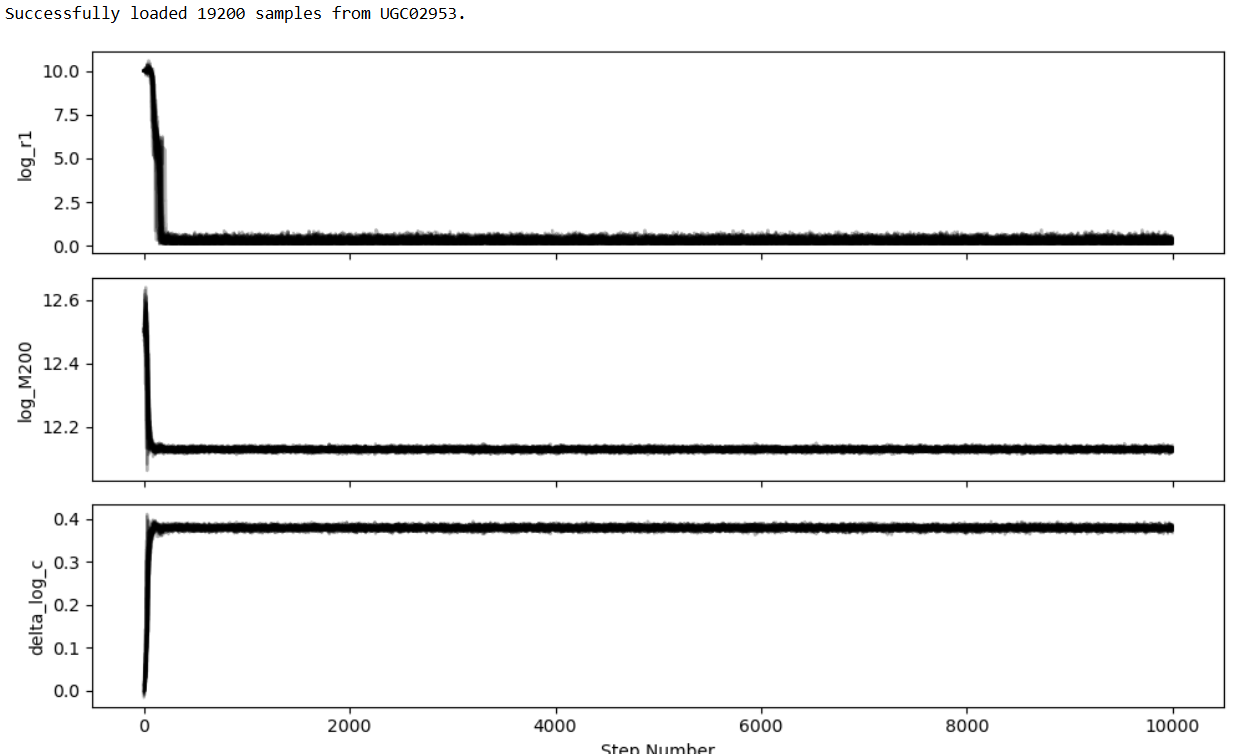
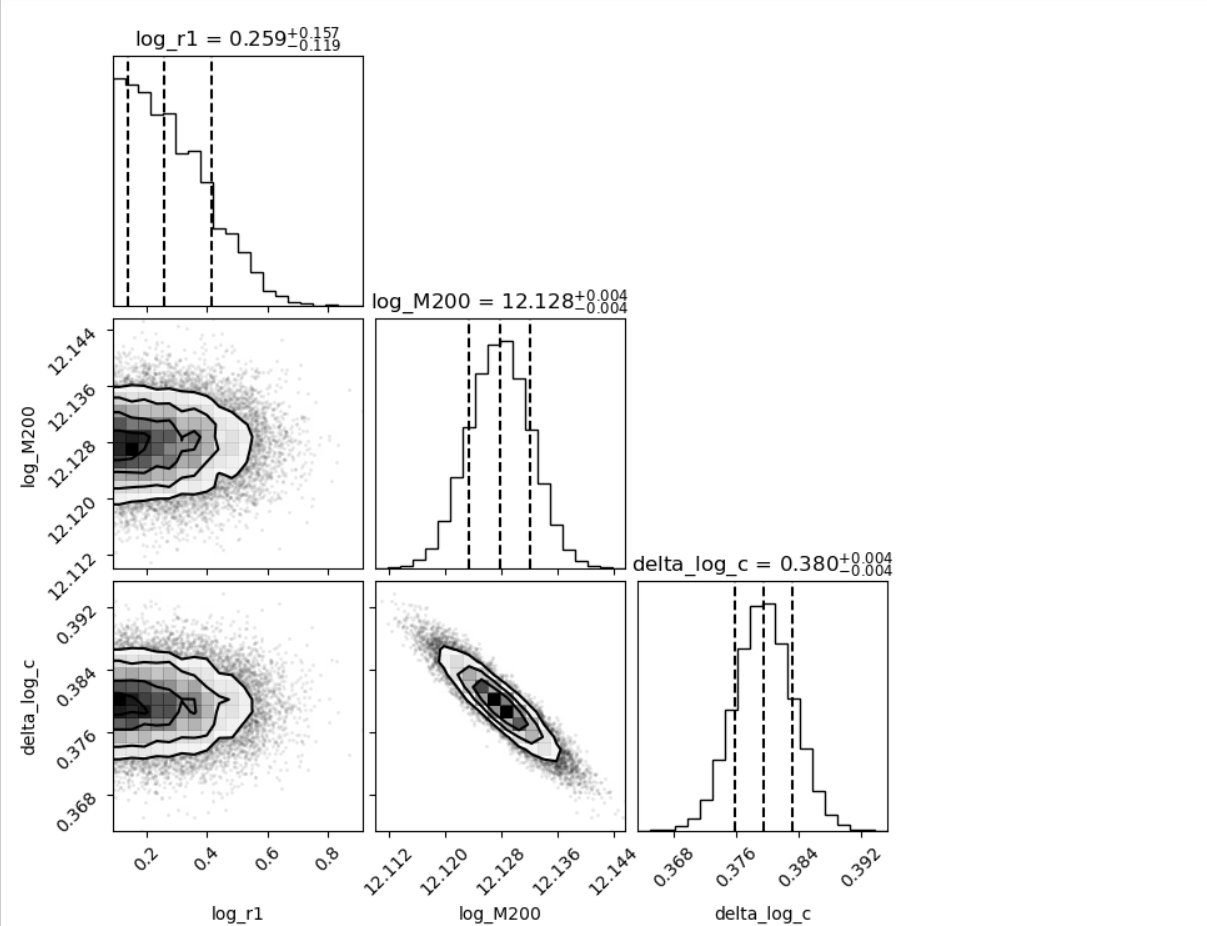
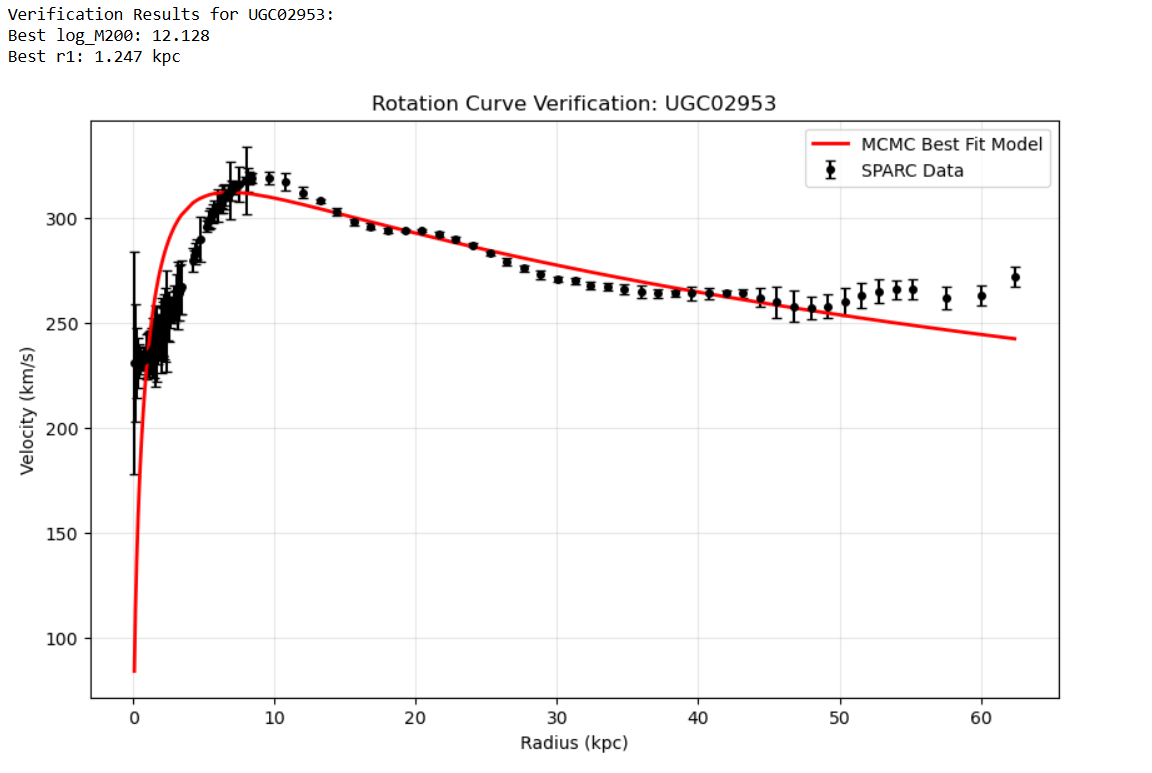


# 3 So what? (What does it mean?)
The integrated analysis of galaxy UGC02953 this week yielded several critical insights into the limitations of our current combined model. While we successfully confirmed a physically valid halo mass of $log_{10}M_{200} \approx 12.128$ and a scale radius $log_{10}r_1 \approx 0.259$, the verification plot highlights a major discrepancy in the inner galactic core. The biggest issue is at the start of the curve, specifically between 0 and 5 kpc. The model (red line) shows an extremely steep, almost vertical rise that overshoots the initial data points before peaking too early around 8 kpc. In contrast, the SPARC data shows a more gradual, "shallower" incline. This suggests that our baryonic Hernquist potential might be too centrally concentrated or "cuspy," creating a gravitational pull that is too strong at very small radii. Furthermore, the model continues to underpredict the velocity in the outer disk beyond 40 kpc, where it drops to $\approx 240$ km/s while the observed data remains flatter at $\approx 275$ km/s. This dual-mismatch—overshooting the start and underpredicting the end, indicates that while our technical pipeline for reading MCMC backends is now operational, the underlying physical parameters for this specific galaxy require further refinement. These results mean that our "Best Fit" is currently a compromise that isn't yet capturing the true mass distribution of UGC02953, serving as a vital diagnostic for the next phase of our research.

# 4. Now what? (What's next?)
This week's progress was great but it revealed potential long term issues with our models. For next week tackling these issues is a priority to ensure that we have a strong basis. To speak more concretely however, next week's objective is to run more h5 mcmc test files then start running our own mcmc tests. Furthermore, we need to integrate our work with the data team so that there is only 1 team rather than 2 working seperately. The data team is working on cutting out galaxies that won't fit our model so that we can ensure consistincy and testing the list of including galaxies will be vital this coming week aswell.

# 5. Bibliography
Lelli, F., McGaugh, S. S., & Schombert, J. M. (2016). SPARC: Mass Models for 175 Late-Type Galaxies with Spitzer Photometry and H i Rotation Curves. The Astronomical Journal.  
Foreman-Mackey, D., Hogg, D. W., Lang, D., & Goodman, J. (2013). emcee: The MCMC Hammer. Publications of the Astronomical Society of the Pacific.